# Inventory Optimization and Replenishment Planning

## Objective

The objective of this notebook is to convert demand analysis and forecasting results into practical inventory planning recommendations.

This notebook focuses on:

1. ABC classification for inventory prioritization.
2. Average daily demand calculation.
3. Demand variability analysis.
4. Safety stock estimation.
5. Reorder point calculation.
6. Replenishment risk classification.
7. Inventory recommendation outputs for Power BI.

The dataset does not contain actual inventory-on-hand levels, so this notebook does not claim confirmed stockouts. Instead, it identifies potential replenishment risk based on demand volume, demand variability, and reorder point estimates.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

The required libraries were imported. Pandas is used for data analysis, NumPy supports numerical calculations, Matplotlib is used for charts, and OS is used for saving output files.

### Setting folder paths

In [39]:
folder = r"C:\Users\DEBIDO\Desktop\favorita-grocery-sales-forecasting"

output_folder = folder + r"\outputs"

os.makedirs(output_folder, exist_ok=True)

The project folder path and output folder were defined. The output folder will be used to save inventory recommendation files for Power BI and reporting.

### Loading the master dataset

In [40]:
master = pd.read_csv(
    folder + r"\final_master_dataset.csv",
    usecols=["date", "store_nbr", "item_nbr", "family", "unit_sales", "onpromotion"]
)

master.head()

,date,store_nbr,item_nbr,unit_sales,onpromotion,family
0,2016-01-01,25,105574,12.0,False,GROCERY I
1,2016-01-01,25,105575,9.0,False,GROCERY I
2,2016-01-01,25,105857,3.0,False,GROCERY I
3,2016-01-01,25,108634,3.0,False,GROCERY I
4,2016-01-01,25,108786,2.0,False,CLEANING


The master dataset was loaded with the columns needed for inventory optimization. The analysis uses date, store, item, product family, demand, and promotion information.

### Convert date column

In [41]:
master["date"] = pd.to_datetime(master["date"])

master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5922347 entries, 0 to 5922346
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   item_nbr     int64         
 3   unit_sales   float64       
 4   onpromotion  bool          
 5   family       object        
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 231.6+ MB


The date column was converted to datetime format so that daily demand and time-based inventory metrics can be calculated correctly.

### Checking basic dataset summary

In [42]:
print("Rows:", master.shape[0])
print("Columns:", master.shape[1])
print("Start date:", master["date"].min())
print("End date:", master["date"].max())
print("Stores:", master["store_nbr"].nunique())
print("Items:", master["item_nbr"].nunique())
print("Product families:", master["family"].nunique())

Rows: 5922347
Columns: 6
Start date: 2016-01-01 00:00:00
End date: 2017-08-15 00:00:00
Stores: 5
Items: 2897
Product families: 8


The dataset summary was checked to confirm the scope of the inventory optimization analysis.

### Aggregating daily demand by store and item

Inventory decisions usually happen at the store-item level, not only family level.

In [43]:
daily_item_demand = master.groupby(
    ["date", "store_nbr", "item_nbr", "family"]
)["unit_sales"].sum().reset_index()

daily_item_demand.head()

,date,store_nbr,item_nbr,family,unit_sales
0,2016-01-01,25,105574,GROCERY I,12.0
1,2016-01-01,25,105575,GROCERY I,9.0
2,2016-01-01,25,105857,GROCERY I,3.0
3,2016-01-01,25,108634,GROCERY I,3.0
4,2016-01-01,25,108786,CLEANING,2.0


Demand was aggregated at the daily store-item level. This creates the structure needed to calculate average demand, demand variability, safety stock, and reorder points.

### Calculating item-level demand summary

In [44]:
item_demand_summary = daily_item_demand.groupby(
    ["store_nbr", "item_nbr", "family"]
).agg(
    total_demand=("unit_sales", "sum"),
    average_daily_demand=("unit_sales", "mean"),
    demand_std=("unit_sales", "std"),
    max_daily_demand=("unit_sales", "max"),
    active_sales_days=("date", "nunique")
).reset_index()

item_demand_summary.head()

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,max_daily_demand,active_sales_days
0,25,96995,GROCERY I,15.0,1.071429,0.267261,2.0,14
1,25,99197,GROCERY I,274.0,2.107692,1.526236,9.0,130
2,25,103520,GROCERY I,206.0,1.980769,1.414082,10.0,104
3,25,103665,BREAD/BAKERY,1062.0,2.824468,2.102960,12.0,376
4,25,105574,GROCERY I,2495.0,5.154959,4.181042,36.0,484


A store-item demand summary was created. This shows total demand, average daily demand, demand variability, maximum daily demand, and the number of active sales days for each item in each store.

### Filling missing standard deviation values

Some items may have only one sales day, so their standard deviation may be missing.

In [45]:
item_demand_summary["demand_std"] = item_demand_summary["demand_std"].fillna(0)

item_demand_summary.isnull().sum()

store_nbr               0
item_nbr                0
family                  0
total_demand            0
average_daily_demand    0
demand_std              0
max_daily_demand        0
active_sales_days       0
dtype: int64

Missing demand standard deviation values were filled with zero. This usually happens when an item has very few sales observations.

### Sales frequency

In [46]:
analysis_days = master["date"].nunique()

item_demand_summary["sales_frequency"] = (
    item_demand_summary["active_sales_days"] / analysis_days
)

item_demand_summary["sales_frequency"] = item_demand_summary["sales_frequency"].round(4)

item_demand_summary.head()

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,max_daily_demand,active_sales_days,sales_frequency
0,25,96995,GROCERY I,15.0,1.071429,0.267261,2.0,14,0.0236
1,25,99197,GROCERY I,274.0,2.107692,1.526236,9.0,130,0.2196
2,25,103520,GROCERY I,206.0,1.980769,1.414082,10.0,104,0.1757
3,25,103665,BREAD/BAKERY,1062.0,2.824468,2.102960,12.0,376,0.6351
4,25,105574,GROCERY I,2495.0,5.154959,4.181042,36.0,484,0.8176


Sales frequency was calculated to show how often each store-item combination recorded sales during the analysis period. This is important because average daily demand is based on active sales days, not necessarily every calendar day in the dataset.

### ABC Analysis at store-item level

ABC analysis helps prioritize inventory.
Using this rule:

A items = items contributing up to 80% of demand

B items = next items contributing up to 95% of demand

C items = remaining items

In [47]:
abc_data = item_demand_summary.sort_values(
    "total_demand",
    ascending=False
).copy()

abc_data["demand_share"] = abc_data["total_demand"] / abc_data["total_demand"].sum()

abc_data["cumulative_demand_share"] = abc_data["demand_share"].cumsum()

def assign_abc_class(cumulative_share):
    if cumulative_share <= 0.80:
        return "A"
    elif cumulative_share <= 0.95:
        return "B"
    else:
        return "C"

abc_data["abc_class"] = abc_data["cumulative_demand_share"].apply(assign_abc_class)

abc_data.head()

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,max_daily_demand,active_sales_days,sales_frequency,demand_share,cumulative_demand_share,abc_class
4753,44,1503844,PRODUCE,422551.761,716.189425,242.704459,1362.554,590,0.9966,0.004737,0.004737,A
13319,49,1503844,PRODUCE,322705.126,546.957841,142.321662,971.224,590,0.9966,0.003617,0.008354,A
4690,44,1473474,PRODUCE,287958.260,488.064847,136.683662,982.696,590,0.9966,0.003228,0.011582,A
3819,44,1047679,BEVERAGES,273768.000,464.013559,199.563215,1561.000,590,0.9966,0.003069,0.014651,A
7612,45,1503844,PRODUCE,273478.790,463.523373,136.380207,880.959,590,0.9966,0.003066,0.017716,A


ABC classification was performed based on total demand contribution. A-items represent the highest-priority products, B-items represent medium-priority products, and C-items represent lower-priority products.

### Checking ABC class distribution

In [48]:
abc_distribution = abc_data["abc_class"].value_counts().reset_index()

abc_distribution.columns = ["abc_class", "number_of_store_items"]

abc_distribution

,abc_class,number_of_store_items
0,C,5324
1,A,4867
2,B,3975


The ABC class distribution shows how many store-item combinations fall into each priority group.

### ABC class distribution

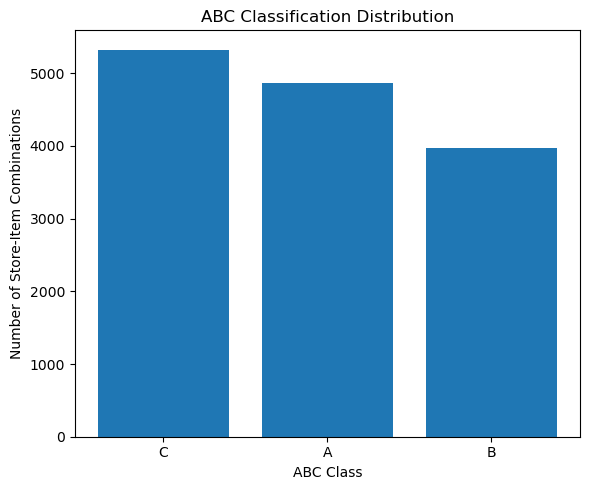

In [49]:
plt.figure(figsize=(6, 5))
plt.bar(abc_distribution["abc_class"], abc_distribution["number_of_store_items"])
plt.title("ABC Classification Distribution")
plt.xlabel("ABC Class")
plt.ylabel("Number of Store-Item Combinations")
plt.tight_layout()
plt.show()

The chart shows the number of store-item combinations in each ABC class. This helps management understand how many products require high, medium, or low inventory attention.

### Demand contribution by ABC class

In [50]:
abc_demand_contribution = abc_data.groupby("abc_class")["total_demand"].sum().reset_index()

abc_demand_contribution["demand_share_percent"] = (
    abc_demand_contribution["total_demand"] / abc_demand_contribution["total_demand"].sum()
) * 100

abc_demand_contribution

,abc_class,total_demand,demand_share_percent
0,A,7.136635e+07,79.997804
1,B,1.338277e+07,15.001356
2,C,4.461269e+06,5.000840


Demand contribution was calculated by ABC class to confirm how much demand is represented by A, B, and C items.

### Demand share by ABC class

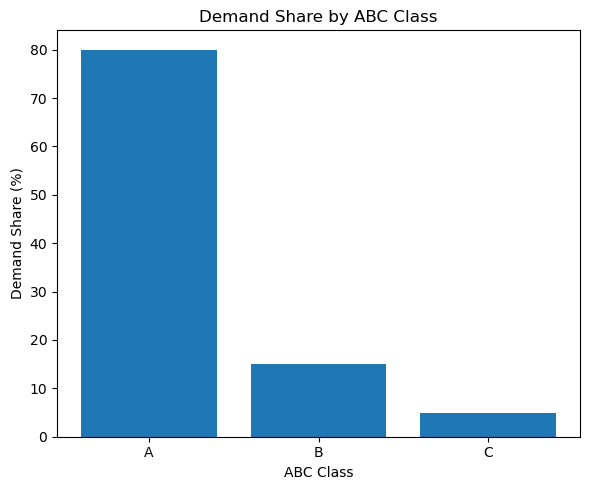

In [51]:
plt.figure(figsize=(6, 5))
plt.bar(
    abc_demand_contribution["abc_class"],
    abc_demand_contribution["demand_share_percent"]
)
plt.title("Demand Share by ABC Class")
plt.xlabel("ABC Class")
plt.ylabel("Demand Share (%)")
plt.tight_layout()
plt.show()

This chart shows the percentage of total demand contributed by each ABC class. A-items should contribute the majority of demand by design.

### Adding inventory planning assumptions

Since the dataset does not contain supplier lead time, i will make clear assumptions.

In [52]:
lead_time_days = 7
service_level_z_score = 1.65

print("Lead time days:", lead_time_days)
print("Service level Z-score:", service_level_z_score)

Lead time days: 7
Service level Z-score: 1.65


Inventory planning assumptions were defined. A 7-day lead time was used to represent the time between placing an order and receiving stock. A Z-score of 1.65 was used to approximate a 95% service level.

### Calculating safety stock

Important note: The dataset does not provide actual inventory-on-hand levels, supplier lead times, or confirmed stockout records. Therefore, the safety stock and reorder point calculations are planning estimates based on observed demand patterns and stated assumptions.

Formula:

Safety Stock = Z-score × Demand Standard Deviation × √Lead Time

In [53]:
abc_data["safety_stock"] = (
    service_level_z_score
    * abc_data["demand_std"]
    * np.sqrt(lead_time_days)
)

abc_data[["store_nbr", "item_nbr", "family", "demand_std", "safety_stock"]].head()

,store_nbr,item_nbr,family,demand_std,safety_stock
4753,44,1503844,PRODUCE,242.704459,1059.523808
13319,49,1503844,PRODUCE,142.321662,621.303744
4690,44,1473474,PRODUCE,136.683662,596.691112
3819,44,1047679,BEVERAGES,199.563215,871.191154
7612,45,1503844,PRODUCE,136.380207,595.366385


Safety stock was calculated to estimate the buffer inventory needed to protect against demand variability during lead time.

### Calculating reorder point

Formula:

Reorder Point = Average Daily Demand × Lead Time + Safety Stock

In [54]:
abc_data["reorder_point"] = (
    abc_data["average_daily_demand"] * lead_time_days
) + abc_data["safety_stock"]

abc_data[[
    "store_nbr",
    "item_nbr",
    "family",
    "average_daily_demand",
    "safety_stock",
    "reorder_point"
]].head()

,store_nbr,item_nbr,family,average_daily_demand,safety_stock,reorder_point
4753,44,1503844,PRODUCE,716.189425,1059.523808,6072.849786
13319,49,1503844,PRODUCE,546.957841,621.303744,4450.008628
4690,44,1473474,PRODUCE,488.064847,596.691112,4013.145044
3819,44,1047679,BEVERAGES,464.013559,871.191154,4119.286069
7612,45,1503844,PRODUCE,463.523373,595.366385,3840.029995


The reorder point was calculated to estimate the inventory level at which a replenishment order should be placed.

### Rounding up inventory metrics

In [55]:
abc_data["average_daily_demand"] = abc_data["average_daily_demand"].round(2)
abc_data["demand_std"] = abc_data["demand_std"].round(2)
abc_data["safety_stock"] = abc_data["safety_stock"].round(2)
abc_data["reorder_point"] = abc_data["reorder_point"].round(2)
abc_data["demand_share"] = abc_data["demand_share"].round(4)
abc_data["cumulative_demand_share"] = abc_data["cumulative_demand_share"].round(4)

abc_data.head()

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,max_daily_demand,active_sales_days,sales_frequency,demand_share,cumulative_demand_share,abc_class,safety_stock,reorder_point
4753,44,1503844,PRODUCE,422551.761,716.19,242.70,1362.554,590,0.9966,0.0047,0.0047,A,1059.52,6072.85
13319,49,1503844,PRODUCE,322705.126,546.96,142.32,971.224,590,0.9966,0.0036,0.0084,A,621.30,4450.01
4690,44,1473474,PRODUCE,287958.260,488.06,136.68,982.696,590,0.9966,0.0032,0.0116,A,596.69,4013.15
3819,44,1047679,BEVERAGES,273768.000,464.01,199.56,1561.000,590,0.9966,0.0031,0.0147,A,871.19,4119.29
7612,45,1503844,PRODUCE,273478.790,463.52,136.38,880.959,590,0.9966,0.0031,0.0177,A,595.37,3840.03


The inventory metrics were rounded to make the recommendation table easier to read and use in Power BI.

### Creating replenishment risk levels

In [56]:
abc_data["coefficient_of_variation"] = (
    abc_data["demand_std"] / abc_data["average_daily_demand"]
)

abc_data["coefficient_of_variation"] = abc_data["coefficient_of_variation"].replace(
    [np.inf, -np.inf],
    0
).fillna(0)

def assign_risk_level(row):
    if row["abc_class"] == "A" and row["coefficient_of_variation"] >= 1:
        return "High Risk"
    elif row["abc_class"] == "A":
        return "Medium Risk"
    elif row["abc_class"] == "B" and row["coefficient_of_variation"] >= 1:
        return "Medium Risk"
    else:
        return "Low Risk"

abc_data["replenishment_risk"] = abc_data.apply(assign_risk_level, axis=1)

abc_data[[
    "store_nbr",
    "item_nbr",
    "family",
    "abc_class",
    "coefficient_of_variation",
    "replenishment_risk"
]].head()

,store_nbr,item_nbr,family,abc_class,coefficient_of_variation,replenishment_risk
4753,44,1503844,PRODUCE,A,0.338877,Medium Risk
13319,49,1503844,PRODUCE,A,0.260202,Medium Risk
4690,44,1473474,PRODUCE,A,0.280048,Medium Risk
3819,44,1047679,BEVERAGES,A,0.430077,Medium Risk
7612,45,1503844,PRODUCE,A,0.294227,Medium Risk


A replenishment risk level was assigned using ABC class and demand variability. High-priority items with unstable demand were classified as higher replenishment risk.

### Checking replenishment risk distribution

In [57]:
risk_distribution = abc_data["replenishment_risk"].value_counts().reset_index()

risk_distribution.columns = ["replenishment_risk", "number_of_store_items"]

risk_distribution

,replenishment_risk,number_of_store_items
0,Low Risk,8560
1,Medium Risk,4972
2,High Risk,634


The replenishment risk distribution shows how many store-item combinations fall into high, medium, or low risk groups.

### Replenishment risk distribution

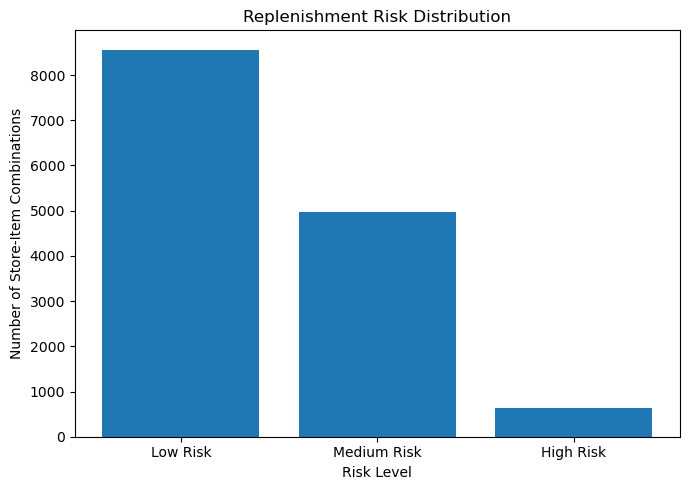

In [58]:
plt.figure(figsize=(7, 5))
plt.bar(
    risk_distribution["replenishment_risk"],
    risk_distribution["number_of_store_items"]
)
plt.title("Replenishment Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Store-Item Combinations")
plt.tight_layout()
plt.show()

The chart summarizes the number of store-item combinations classified as high, medium, or low replenishment risk.

### Top high-risk items

In [59]:
high_risk_items = abc_data[
    abc_data["replenishment_risk"] == "High Risk"
].sort_values(
    "reorder_point",
    ascending=False
)

high_risk_items.head(10)

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,max_daily_demand,active_sales_days,sales_frequency,demand_share,cumulative_demand_share,abc_class,safety_stock,reorder_point,coefficient_of_variation,replenishment_risk
6119,45,559870,GROCERY I,67276.0,114.03,852.85,20748.0,590,0.9966,0.0008,0.1182,A,3723.09,4521.28,7.479172,High Risk
3583,44,856688,GROCERY I,10558.0,285.35,402.96,1641.0,37,0.0625,0.0001,0.5706,A,1759.13,3756.59,1.412161,High Risk
3582,44,856687,GROCERY I,8914.0,240.92,372.23,1571.0,37,0.0625,0.0001,0.6257,A,1624.98,3311.42,1.545036,High Risk
6444,45,856688,GROCERY I,8106.0,225.17,389.11,1745.0,36,0.0608,0.0001,0.6574,A,1698.67,3274.84,1.728072,High Risk
5801,45,265559,GROCERY I,81822.0,138.68,501.75,12228.0,590,0.9966,0.0009,0.0891,A,2190.40,3161.17,3.618042,High Risk
6443,45,856687,GROCERY I,8467.0,217.10,346.63,1596.0,39,0.0659,0.0001,0.6429,A,1513.21,3032.93,1.596637,High Risk
12153,49,856687,GROCERY I,7299.0,221.18,306.50,1226.0,33,0.0557,0.0001,0.6907,A,1338.03,2886.30,1.385749,High Risk
10166,47,1430040,BEVERAGES,106783.0,184.11,296.34,6932.0,580,0.9797,0.0012,0.0552,A,1293.66,2582.42,1.609581,High Risk
9304,47,856687,GROCERY I,6329.0,186.15,279.33,1284.0,34,0.0574,0.0001,0.7359,A,1219.40,2522.43,1.500564,High Risk
11609,49,354964,GROCERY I,8983.0,169.49,289.28,1495.0,53,0.0895,0.0001,0.6230,A,1262.83,2449.26,1.706767,High Risk


The top high-risk items were identified based on replenishment risk and reorder point. These items require closer monitoring because they combine high importance with demand instability.

### Inventory recommendations by family

In [60]:
family_inventory_summary = abc_data.groupby("family").agg(
    total_demand=("total_demand", "sum"),
    average_reorder_point=("reorder_point", "mean"),
    average_safety_stock=("safety_stock", "mean"),
    high_risk_items=("replenishment_risk", lambda x: (x == "High Risk").sum()),
    medium_risk_items=("replenishment_risk", lambda x: (x == "Medium Risk").sum()),
    low_risk_items=("replenishment_risk", lambda x: (x == "Low Risk").sum())
).reset_index()

family_inventory_summary = family_inventory_summary.sort_values(
    "total_demand",
    ascending=False
)

family_inventory_summary

,family,total_demand,average_reorder_point,average_safety_stock,high_risk_items,medium_risk_items,low_risk_items
4,GROCERY I,2.542437e+07,105.061848,38.536445,286,1657,3858
0,BEVERAGES,2.261576e+07,201.923067,73.155793,257,1083,1546
7,PRODUCE,1.962363e+07,262.654573,64.087402,19,832,450
3,DAIRY,6.407897e+06,104.819904,27.402539,6,476,660
2,CLEANING,6.033051e+06,69.504272,24.103327,46,400,1532
1,BREAD/BAKERY,3.482735e+06,118.921771,31.090667,9,225,291
6,POULTRY,3.111344e+06,231.952267,64.268623,3,151,93
5,MEATS,2.511597e+06,167.701503,45.764930,8,148,130


Inventory metrics were summarized by product family to identify which categories require the most replenishment attention.

### High-risk items by family

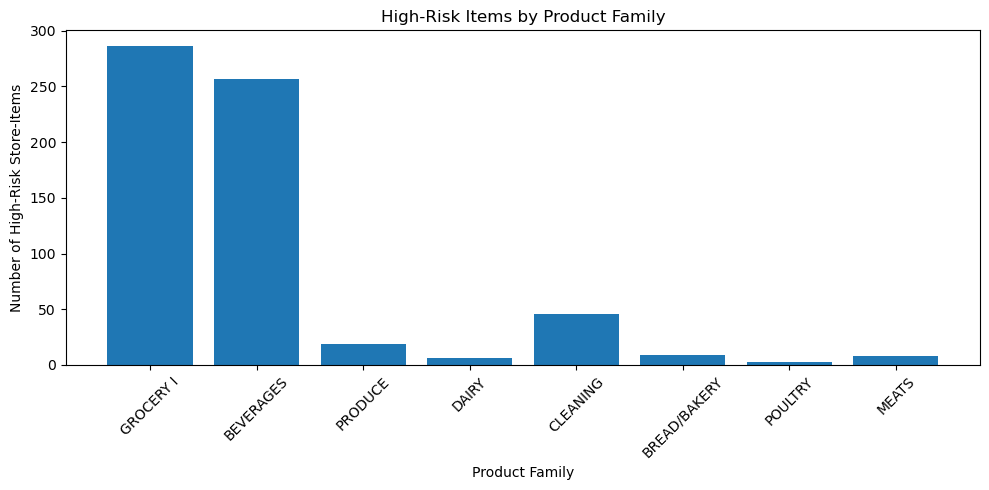

In [61]:
plt.figure(figsize=(10, 5))
plt.bar(
    family_inventory_summary["family"],
    family_inventory_summary["high_risk_items"]
)
plt.title("High-Risk Items by Product Family")
plt.xlabel("Product Family")
plt.ylabel("Number of High-Risk Store-Items")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows which product families contain the highest number of high-risk store-item combinations.

### Inventory recommendations by store

In [62]:
store_inventory_summary = abc_data.groupby("store_nbr").agg(
    total_demand=("total_demand", "sum"),
    average_reorder_point=("reorder_point", "mean"),
    average_safety_stock=("safety_stock", "mean"),
    high_risk_items=("replenishment_risk", lambda x: (x == "High Risk").sum()),
    medium_risk_items=("replenishment_risk", lambda x: (x == "Medium Risk").sum()),
    low_risk_items=("replenishment_risk", lambda x: (x == "Low Risk").sum())
).reset_index()

store_inventory_summary = store_inventory_summary.sort_values(
    "total_demand",
    ascending=False
)

store_inventory_summary

,store_nbr,total_demand,average_reorder_point,average_safety_stock,high_risk_items,medium_risk_items,low_risk_items
1,44,2.411947e+07,175.675066,55.843245,188,1307,1371
2,45,2.172711e+07,170.524661,59.237845,155,1230,1473
3,47,2.013586e+07,153.801342,51.314805,165,1165,1523
4,49,1.902923e+07,136.320877,40.397674,83,1073,1694
0,25,4.198712e+06,51.349379,18.776210,43,197,2499


Inventory metrics were summarized by store to identify which retail locations require the most inventory planning attention.

### High-risk items by store

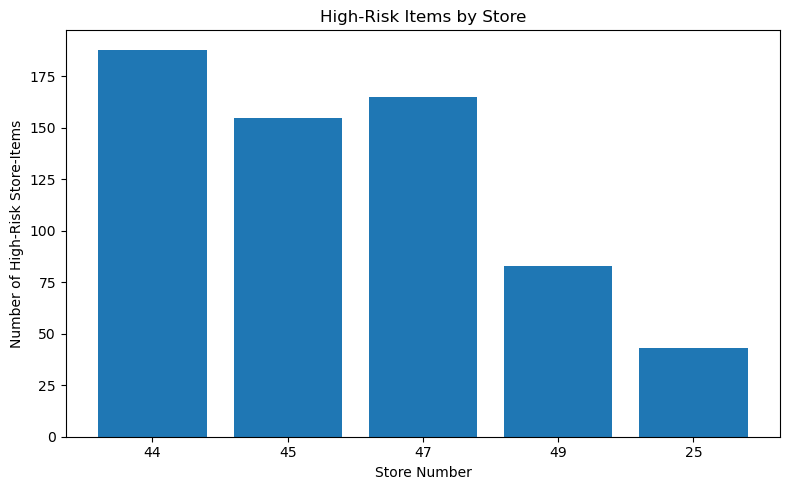

In [63]:
plt.figure(figsize=(8, 5))
plt.bar(
    store_inventory_summary["store_nbr"].astype(str),
    store_inventory_summary["high_risk_items"]
)
plt.title("High-Risk Items by Store")
plt.xlabel("Store Number")
plt.ylabel("Number of High-Risk Store-Items")
plt.tight_layout()
plt.show()

The chart shows which stores have the highest number of high-risk store-item combinations.

### Final recommendation table

In [64]:
inventory_recommendations = abc_data[[
    "store_nbr",
    "item_nbr",
    "family",
    "total_demand",
    "average_daily_demand",
    "demand_std",
    "active_sales_days",
    "sales_frequency",
    "coefficient_of_variation",
    "abc_class",
    "safety_stock",
    "reorder_point",
    "replenishment_risk"
]].copy()

inventory_recommendations = inventory_recommendations.sort_values(
    ["replenishment_risk", "abc_class", "reorder_point"],
    ascending=[True, True, False]
)

inventory_recommendations.head(20)

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,active_sales_days,sales_frequency,coefficient_of_variation,abc_class,safety_stock,reorder_point,replenishment_risk
6119,45,559870,GROCERY I,67276.0,114.03,852.85,590,0.9966,7.479172,A,3723.09,4521.28,High Risk
3583,44,856688,GROCERY I,10558.0,285.35,402.96,37,0.0625,1.412161,A,1759.13,3756.59,High Risk
3582,44,856687,GROCERY I,8914.0,240.92,372.23,37,0.0625,1.545036,A,1624.98,3311.42,High Risk
6444,45,856688,GROCERY I,8106.0,225.17,389.11,36,0.0608,1.728072,A,1698.67,3274.84,High Risk
5801,45,265559,GROCERY I,81822.0,138.68,501.75,590,0.9966,3.618042,A,2190.40,3161.17,High Risk
6443,45,856687,GROCERY I,8467.0,217.10,346.63,39,0.0659,1.596637,A,1513.21,3032.93,High Risk
12153,49,856687,GROCERY I,7299.0,221.18,306.50,33,0.0557,1.385749,A,1338.03,2886.30,High Risk
10166,47,1430040,BEVERAGES,106783.0,184.11,296.34,580,0.9797,1.609581,A,1293.66,2582.42,High Risk
9304,47,856687,GROCERY I,6329.0,186.15,279.33,34,0.0574,1.500564,A,1219.40,2522.43,High Risk
11609,49,354964,GROCERY I,8983.0,169.49,289.28,53,0.0895,1.706767,A,1262.83,2449.26,High Risk


A final inventory recommendation table was created. This table combines ABC class, safety stock, reorder point, and replenishment risk for each store-item combination.

### Improving sorting order for risk levels

In [65]:
risk_order = {
    "High Risk": 1,
    "Medium Risk": 2,
    "Low Risk": 3
}

abc_order = {
    "A": 1,
    "B": 2,
    "C": 3
}

inventory_recommendations["risk_order"] = inventory_recommendations["replenishment_risk"].map(risk_order)
inventory_recommendations["abc_order"] = inventory_recommendations["abc_class"].map(abc_order)

inventory_recommendations = inventory_recommendations.sort_values(
    ["risk_order", "abc_order", "reorder_point"],
    ascending=[True, True, False]
)

inventory_recommendations = inventory_recommendations.drop(
    columns=["risk_order", "abc_order"]
)

inventory_recommendations.head(20)

,store_nbr,item_nbr,family,total_demand,average_daily_demand,demand_std,active_sales_days,sales_frequency,coefficient_of_variation,abc_class,safety_stock,reorder_point,replenishment_risk
6119,45,559870,GROCERY I,67276.0,114.03,852.85,590,0.9966,7.479172,A,3723.09,4521.28,High Risk
3583,44,856688,GROCERY I,10558.0,285.35,402.96,37,0.0625,1.412161,A,1759.13,3756.59,High Risk
3582,44,856687,GROCERY I,8914.0,240.92,372.23,37,0.0625,1.545036,A,1624.98,3311.42,High Risk
6444,45,856688,GROCERY I,8106.0,225.17,389.11,36,0.0608,1.728072,A,1698.67,3274.84,High Risk
5801,45,265559,GROCERY I,81822.0,138.68,501.75,590,0.9966,3.618042,A,2190.40,3161.17,High Risk
6443,45,856687,GROCERY I,8467.0,217.10,346.63,39,0.0659,1.596637,A,1513.21,3032.93,High Risk
12153,49,856687,GROCERY I,7299.0,221.18,306.50,33,0.0557,1.385749,A,1338.03,2886.30,High Risk
10166,47,1430040,BEVERAGES,106783.0,184.11,296.34,580,0.9797,1.609581,A,1293.66,2582.42,High Risk
9304,47,856687,GROCERY I,6329.0,186.15,279.33,34,0.0574,1.500564,A,1219.40,2522.43,High Risk
11609,49,354964,GROCERY I,8983.0,169.49,289.28,53,0.0895,1.706767,A,1262.83,2449.26,High Risk


The recommendation table was sorted so that high-risk and high-priority items appear first. This makes the output more useful for decision-making.

### Saving inventory outputs

In [66]:
abc_data.to_csv(
    output_folder + r"\abc_inventory_analysis.csv",
    index=False
)

inventory_recommendations.to_csv(
    output_folder + r"\inventory_recommendations.csv",
    index=False
)

family_inventory_summary.to_csv(
    output_folder + r"\family_inventory_summary.csv",
    index=False
)

store_inventory_summary.to_csv(
    output_folder + r"\store_inventory_summary.csv",
    index=False
)

high_risk_items.to_csv(
    output_folder + r"\high_risk_inventory_items.csv",
    index=False
)

print("Inventory optimization outputs saved successfully.")

Inventory optimization outputs saved successfully.


Inventory optimization outputs were saved for Power BI dashboard development and final project reporting.

### Final inventory insights

## Inventory Optimization Insights

## Key Inventory Results

- Total store-item combinations analyzed: 14,166
- A-class store-items: 4,867
- B-class store-items: 3,975
- C-class store-items: 5,324
- A-items contributed approximately 80.00% of total demand.
- B-items contributed approximately 15.00% of total demand.
- C-items contributed approximately 5.00% of total demand.
- High-risk store-items identified: 634
- Medium-risk store-items identified: 4,972
- Low-risk store-items identified: 8,560
- Store 44 had the highest total demand and the highest number of high-risk items.
- `GROCERY I` had the highest total demand and the highest number of high-risk items.

1. ABC classification was used to prioritize store-item combinations based on demand contribution.

2. A-items represent the highest-priority inventory items because they contribute the majority of total demand.

3. Safety stock was calculated using demand variability, a 7-day lead time assumption, and a 95% service level approximation.

4. Reorder points were estimated using average daily demand, lead time, and safety stock.

5. Replenishment risk was classified using ABC priority and demand variability.

6. High-risk items should be monitored more closely because they combine high demand importance with unstable demand patterns.

7. Product families with many high-risk items should receive stronger replenishment attention.

8. Stores with many high-risk items may require closer inventory review and more frequent replenishment planning.

## Business Interpretation

The inventory optimization analysis converts historical demand into practical replenishment recommendations. By combining ABC classification, safety stock, reorder points, and replenishment risk, the business can prioritize which products require closer monitoring and when replenishment action may be needed.

Because actual inventory-on-hand data is not available, the analysis identifies potential replenishment risk rather than confirmed stockout events.

## Conclusion

This notebook translated demand analysis into inventory planning recommendations.

The analysis classified products using ABC analysis, estimated safety stock, calculated reorder points, and identified potential replenishment risk across selected stores and product families.

These outputs will support the Power BI dashboard by providing decision-ready inventory metrics for management.